In [25]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.ensemble import RandomForestRegressor
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score, accuracy_score, classification_report
from statsmodels.stats.outliers_influence import variance_inflation_factor
import warnings
warnings.filterwarnings('ignore')


In [26]:
# Đọc dữ liệu từ file CSV 
test_df = pd.read_csv("food_consumption_16.csv", sep=',')
train_df = pd.read_csv("food_consumption_14.csv", sep=',')
display(train_df.head(), test_df.head())


,h_code,tinh,household_size,head_gender,head_age,area_type1,area_type2,outpatient_visits,outpatient_cost,inpatient_visits,...,insurance_outpatient,insurance_inpatient,medicine_cost,equipment_cost,health_subsidy,thubq,thunhap,salary,other_income,actual_food_2014
0,10010000400815,1,5,1,35,1,1,3.0,1310.0,0.0,...,2.0,2.0,980,150,0,9876,592600.0,297600.0,295000,27163.0
1,10010002802514,1,5,2,63,1,1,1.0,600.0,0.0,...,2.0,2.0,1500,200,150,3760,225650.0,181500.0,44000,14542.0
2,10020006701613,1,5,1,53,1,1,1.0,950.0,0.0,...,2.0,2.0,870,100,0,4698,281894.0,69500.0,6800,9611.0
3,10040013903013,1,1,1,54,1,1,NaN,NaN,NaN,...,2.0,2.0,300,0,0,9541,114500.0,98000.0,16500,2740.0
4,10050016703013,1,2,1,65,25,1,2.0,600.0,0.0,...,2.0,2.0,100,30,0,15340,368180.0,330180.0,38000,7351.5


,h_code,tinh,household_size,head_gender,head_age,area_type1,area_type2,outpatient_visits,outpatient_cost,inpatient_visits,...,insurance_outpatient,insurance_inpatient,medicine_cost,equipment_cost,health_subsidy,thubq,thunhap,salary,other_income,actual_food_2016
0,10010000400815,1,5,1,37,1,1,NaN,NaN,NaN,...,2.0,2.0,670,200,0,10710,642600.0,415600.0,155000.0,24578.0
1,10010002802514,1,5,2,64,1,1,2.0,2100.0,0.0,...,2.0,2.0,1800,0,3000,3635,218100.0,208100.0,7000.0,11518.0
2,10020006701613,1,6,1,55,1,1,1.0,0.0,0.0,...,1.0,1.0,900,200,10000,5101,367300.0,232000.0,22000.0,7707.0
3,10040013903013,1,1,1,56,1,1,2.0,1300.0,0.0,...,1.0,2.0,500,50,300,10141,121700.0,97000.0,24400.0,4821.0
4,10050016703013,1,2,1,67,25,1,NaN,NaN,NaN,...,2.0,2.0,1500,50,0,11416,274000.0,220000.0,54000.0,5480.7


In [27]:
test_df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1635 entries, 0 to 1634
Data columns (total 22 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   h_code                1635 non-null   int64  
 1   tinh                  1635 non-null   int64  
 2   household_size        1635 non-null   int64  
 3   head_gender           1635 non-null   int64  
 4   head_age              1635 non-null   int64  
 5   area_type1            1635 non-null   int64  
 6   area_type2            1635 non-null   int64  
 7   outpatient_visits     1227 non-null   float64
 8   outpatient_cost       1135 non-null   float64
 9   inpatient_visits      1227 non-null   float64
 10  inpatient_cost        377 non-null    float64
 11  insurance_premium     884 non-null    float64
 12  insurance_outpatient  1514 non-null   float64
 13  insurance_inpatient   1514 non-null   float64
 14  medicine_cost         1635 non-null   int64  
 15  equipment_cost       

In [28]:
train_df.info() 


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1635 entries, 0 to 1634
Data columns (total 22 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   h_code                1635 non-null   int64  
 1   tinh                  1635 non-null   int64  
 2   household_size        1635 non-null   int64  
 3   head_gender           1635 non-null   int64  
 4   head_age              1635 non-null   int64  
 5   area_type1            1635 non-null   int64  
 6   area_type2            1635 non-null   int64  
 7   outpatient_visits     1211 non-null   float64
 8   outpatient_cost       1100 non-null   float64
 9   inpatient_visits      1211 non-null   float64
 10  inpatient_cost        387 non-null    float64
 11  insurance_premium     849 non-null    float64
 12  insurance_outpatient  1507 non-null   float64
 13  insurance_inpatient   1507 non-null   float64
 14  medicine_cost         1635 non-null   int64  
 15  equipment_cost       

In [29]:
test_df.isnull().sum()

h_code                     0
tinh                       0
household_size             0
head_gender                0
head_age                   0
area_type1                 0
area_type2                 0
outpatient_visits        408
outpatient_cost          500
inpatient_visits         408
inpatient_cost          1258
insurance_premium        751
insurance_outpatient     121
insurance_inpatient      121
medicine_cost              0
equipment_cost             0
health_subsidy             0
thubq                      0
thunhap                    0
salary                     0
other_income               0
actual_food_2016           0
dtype: int64

In [30]:
# Xử lý giá trị thiếu trong tập test_df
# Fill missing values for continuous variables with mean (only keep columns that exist)
numerical_cols = ['outpatient_visits', 'outpatient_cost', 'inpatient_visits', 'inpatient_cost',
                  'insurance_premium']
numerical_cols = [col for col in numerical_cols if col in test_df.columns]

for col in numerical_cols:
    mean_val = test_df[col].mean()
    test_df[col].fillna(mean_val, inplace=True)

# Fill missing values for categorical-like variables with mode (only if they exist)
categorical_cols = ['insurance_outpatient', 'insurance_inpatient']
categorical_cols = [col for col in categorical_cols if col in test_df.columns]

for col in categorical_cols:
    modes = test_df[col].mode()
    if not modes.empty:
        test_df[col].fillna(modes.iloc[0], inplace=True)
    else:
        test_df[col].fillna(0, inplace=True)
# Quick check
print("Missing values after imputation:")
print(test_df[numerical_cols + categorical_cols].isnull().sum())

Missing values after imputation:
outpatient_visits       0
outpatient_cost         0
inpatient_visits        0
inpatient_cost          0
insurance_premium       0
insurance_outpatient    0
insurance_inpatient     0
dtype: int64


In [31]:
train_df.isnull().sum()

h_code                     0
tinh                       0
household_size             0
head_gender                0
head_age                   0
area_type1                 0
area_type2                 0
outpatient_visits        424
outpatient_cost          535
inpatient_visits         424
inpatient_cost          1248
insurance_premium        786
insurance_outpatient     128
insurance_inpatient      128
medicine_cost              0
equipment_cost             0
health_subsidy             0
thubq                      0
thunhap                    0
salary                     0
other_income               0
actual_food_2014           0
dtype: int64

In [32]:
# Fill missing values for continuous variables with mean (only keep columns that exist)
numerical_cols = ['outpatient_visits', 'outpatient_cost', 'inpatient_visits', 'inpatient_cost',
                  'insurance_premium']
numerical_cols = [col for col in numerical_cols if col in train_df.columns]

for col in numerical_cols:
    mean_val = train_df[col].mean()
    train_df[col].fillna(mean_val, inplace=True)

# Fill missing values for categorical-like variables with mode (only if they exist)
categorical_cols = ['insurance_outpatient', 'insurance_inpatient']
categorical_cols = [col for col in categorical_cols if col in train_df.columns]

for col in categorical_cols:
    modes = train_df[col].mode()
    if not modes.empty:
        train_df[col].fillna(modes.iloc[0], inplace=True)
    else:
        train_df[col].fillna(0, inplace=True)

# Quick check
print("Missing values after imputation:")
print(train_df[numerical_cols + categorical_cols].isnull().sum())

Missing values after imputation:
outpatient_visits       0
outpatient_cost         0
inpatient_visits        0
inpatient_cost          0
insurance_premium       0
insurance_outpatient    0
insurance_inpatient     0
dtype: int64


In [33]:
summary_test = test_df.describe(include='all')
summary_train = train_df.describe(include='all')
display(summary_test, summary_train)

,h_code,tinh,household_size,head_gender,head_age,area_type1,area_type2,outpatient_visits,outpatient_cost,inpatient_visits,...,insurance_outpatient,insurance_inpatient,medicine_cost,equipment_cost,health_subsidy,thubq,thunhap,salary,other_income,actual_food_2016
count,1.635000e+03,1635.000000,1635.000000,1635.000000,1635.000000,1635.000000,1635.000000,1635.000000,1635.000000,1635.000000,...,1635.000000,1635.000000,1635.000000,1635.000000,1635.000000,1635.000000,1.635000e+03,1635.000000,1.635000e+03,1635.000000
mean,4.776141e+14,47.285015,3.722324,1.245260,52.735168,45.686850,1.007339,2.618582,994.991189,0.287694,...,1.692355,1.901529,871.949847,75.234862,805.388991,2929.987156,1.252096e+05,56250.162080,1.380559e+04,4841.603547
std,2.775770e+14,27.488299,1.577057,0.430373,13.790448,26.746551,0.098681,2.836367,2131.440776,0.785987,...,0.461660,0.298042,2059.991315,252.108314,3358.905405,2571.303865,1.132094e+05,75887.195296,3.779971e+04,4606.518367
min,1.001000e+13,1.000000,1.000000,1.000000,17.000000,1.000000,1.000000,0.000000,0.000000,0.000000,...,1.000000,1.000000,0.000000,0.000000,0.000000,115.000000,2.765000e+03,0.000000,0.000000e+00,376.000000
25%,2.523708e+14,25.000000,3.000000,1.000000,43.000000,26.000000,1.000000,1.000000,110.000000,0.000000,...,1.000000,2.000000,180.000000,0.000000,0.000000,1419.500000,5.352600e+04,0.000000,8.700000e+02,2470.000000
50%,4.445519e+14,44.000000,4.000000,1.000000,52.000000,40.000000,1.000000,2.618582,750.000000,0.000000,...,2.000000,2.000000,400.000000,0.000000,0.000000,2333.000000,9.695000e+04,33560.000000,3.200000e+03,3800.000000
75%,7.271026e+14,72.000000,5.000000,1.000000,61.000000,68.000000,1.000000,3.000000,994.991189,0.287694,...,2.000000,2.000000,772.500000,60.000000,200.000000,3712.500000,1.591425e+05,81550.000000,1.320050e+04,5969.000000
max,9.697332e+14,96.000000,12.000000,2.000000,99.000000,99.000000,3.000000,36.000000,48000.000000,15.000000,...,2.000000,2.000000,38000.000000,6000.000000,58000.000000,39181.000000,1.410550e+06,640300.000000,1.015050e+06,92958.000000


,h_code,tinh,household_size,head_gender,head_age,area_type1,area_type2,outpatient_visits,outpatient_cost,inpatient_visits,...,insurance_outpatient,insurance_inpatient,medicine_cost,equipment_cost,health_subsidy,thubq,thunhap,salary,other_income,actual_food_2014
count,1.635000e+03,1635.000000,1635.000000,1635.000000,1635.000000,1635.000000,1635.000000,1635.000000,1635.000000,1635.000000,...,1635.000000,1635.000000,1635.000000,1635.000000,1635.000000,1635.000000,1.635000e+03,1635.000000,1.635000e+03,1635.000000
mean,4.776141e+14,47.285015,3.793884,1.236697,51.395107,45.476453,1.014679,2.529315,982.081818,0.263419,...,1.751070,1.923547,816.387156,56.911927,737.585321,2548.612232,1.110556e+05,48243.047095,1.198320e+04,4484.486361
std,2.775770e+14,27.488299,1.565685,0.425185,13.925109,26.949177,0.147703,2.996705,2927.891568,0.572188,...,0.432525,0.265802,1828.829267,275.759382,4087.083086,3060.650039,1.323976e+05,69381.575954,4.596503e+04,3761.977140
min,1.001000e+13,1.000000,1.000000,1.000000,16.000000,1.000000,1.000000,0.000000,0.000000,0.000000,...,1.000000,1.000000,0.000000,0.000000,0.000000,194.000000,3.530000e+03,0.000000,0.000000e+00,360.000000
25%,2.523708e+14,25.000000,3.000000,1.000000,41.000000,26.000000,1.000000,1.000000,120.000000,0.000000,...,2.000000,2.000000,200.000000,0.000000,0.000000,1139.500000,4.708200e+04,0.000000,5.500000e+02,2311.500000
50%,4.445519e+14,44.000000,4.000000,1.000000,50.000000,40.000000,1.000000,2.000000,680.000000,0.000000,...,2.000000,2.000000,360.000000,0.000000,0.000000,1906.000000,8.345000e+04,24960.000000,2.460000e+03,3558.000000
75%,7.271026e+14,72.000000,5.000000,1.000000,59.500000,68.000000,1.000000,2.529315,982.081818,0.263419,...,2.000000,2.000000,720.000000,50.000000,0.000000,3064.000000,1.377930e+05,69420.000000,8.935000e+03,5460.000000
max,9.697332e+14,96.000000,13.000000,2.000000,97.000000,99.000000,3.000000,48.000000,72000.000000,7.000000,...,2.000000,2.000000,35000.000000,8690.000000,105000.000000,68058.000000,2.646980e+06,654000.000000,1.035000e+06,55787.000000


In [34]:
# Mã hóa biến định tính bằng LabelEncoder
le = LabelEncoder()
for col in ['tinh', 'head_gender', 'area_type2', 'insurance_outpatient', 'insurance_inpatient']:
    test_df[col] = le.fit_transform(test_df[col])
    train_df[col] = le.fit_transform(train_df[col])
    
# Kiểm tra phân phối biến mục tiêu
print("\nPhân phối biến mục tiêu actual_food_2016:")
print(test_df['actual_food_2016'].describe())
print("\nPhân phối biến mục tiêu actual_food_2014:")
print(train_df['actual_food_2014'].describe())




Phân phối biến mục tiêu actual_food_2016:
count     1635.000000
mean      4841.603547
std       4606.518367
min        376.000000
25%       2470.000000
50%       3800.000000
75%       5969.000000
max      92958.000000
Name: actual_food_2016, dtype: float64

Phân phối biến mục tiêu actual_food_2014:
count     1635.000000
mean      4484.486361
std       3761.977140
min        360.000000
25%       2311.500000
50%       3558.000000
75%       5460.000000
max      55787.000000
Name: actual_food_2014, dtype: float64



Tầm quan trọng của các đặc trưng:
                Variable  Importance
17               thunhap    0.389287
18                salary    0.092709
10     insurance_premium    0.088531
1         household_size    0.083915
16                 thubq    0.056424
19          other_income    0.056219
13         medicine_cost    0.046820
3               head_age    0.035659
7        outpatient_cost    0.032234
4             area_type1    0.028446
0                   tinh    0.023660
14        equipment_cost    0.017471
6      outpatient_visits    0.017301
9         inpatient_cost    0.012709
15        health_subsidy    0.004775
8       inpatient_visits    0.004706
11  insurance_outpatient    0.004087
2            head_gender    0.003849
12   insurance_inpatient    0.000716
5             area_type2    0.000481


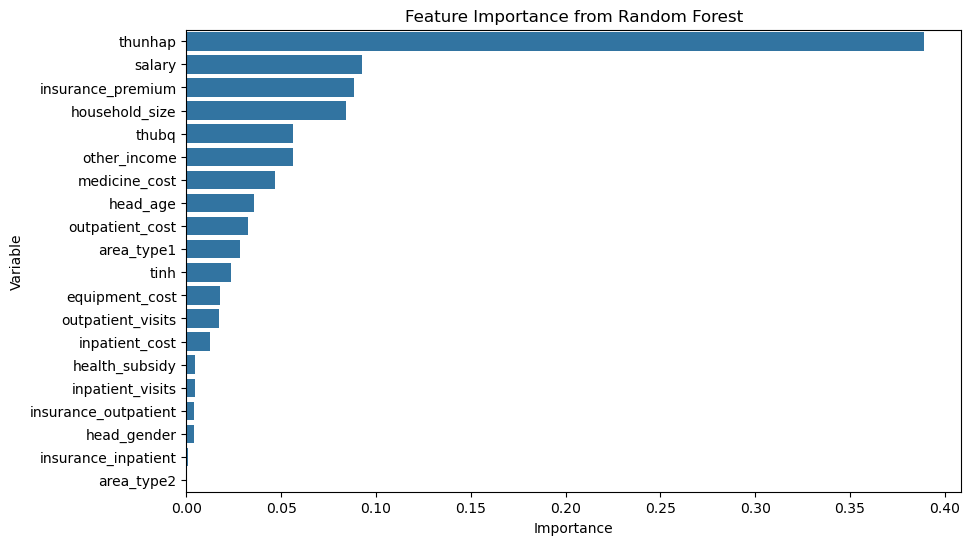


Các biến quan trọng được giữ lại: ['thunhap', 'salary', 'insurance_premium', 'household_size', 'thubq', 'other_income']


,thunhap,salary,insurance_premium,household_size,thubq,other_income,actual_food_2016
0,642600.0,415600.0,457.000000,5,10710,155000.0,24578.0
1,218100.0,208100.0,435.000000,5,3635,7000.0,11518.0
2,367300.0,232000.0,650.000000,6,5101,22000.0,7707.0
3,121700.0,97000.0,499.695701,1,10141,24400.0,4821.0
4,274000.0,220000.0,499.695701,2,11416,54000.0,5480.7


In [35]:
# Sử dụng Random Forest để đánh giá tầm quan trọng của các đặc trưng
X = test_df.drop(['actual_food_2016', 'h_code'], axis=1)
y = test_df['actual_food_2016']
rf = RandomForestRegressor(n_estimators=100, random_state=42)
rf.fit(X, y)

# Tầm quan trọng của các đặc trưng
feature_importance = pd.DataFrame({'Variable': X.columns, 'Importance': rf.feature_importances_})
feature_importance = feature_importance.sort_values(by='Importance', ascending=False)
print("\nTầm quan trọng của các đặc trưng:")
print(feature_importance)

# Vẽ biểu đồ tầm quan trọng của các đặc trưng
plt.figure(figsize=(10, 6))
sns.barplot(x='Importance', y='Variable', data=feature_importance)
plt.title('Feature Importance from Random Forest')
plt.xlabel('Importance')
plt.ylabel('Variable')
plt.show()

# Chọn các biến quan trọng (giữ lại các biến có tầm quan trọng > 0.05)
important_features = feature_importance[feature_importance['Importance'] > 0.05]['Variable'].tolist()
print("\nCác biến quan trọng được giữ lại:", important_features)

# Tạo DataFrame mới chỉ chứa các biến quan trọng và actual_food_2016
test_df = test_df[important_features + ['actual_food_2016']]
test_df.head()

In [36]:
#  Tách features (X) và target (y) tập test
continuous_vars_test = []
discrete_vars_test = []

for col in test_df.columns:
    if col != 'actual_food_2016':
        if test_df[col].dtype in ['int64', 'float64'] and test_df[col].nunique() > 15:
            continuous_vars_test.append(col)
        else:
            discrete_vars_test.append(col)

print("\nBiến liên tục:", continuous_vars_test)
print("Biến rời rạc:", discrete_vars_test)


Biến liên tục: ['thunhap', 'salary', 'insurance_premium', 'thubq', 'other_income']
Biến rời rạc: ['household_size']



Tầm quan trọng của các đặc trưng:
                Variable  Importance
17               thunhap    0.424557
18                salary    0.102164
10     insurance_premium    0.061800
16                 thubq    0.050465
4             area_type1    0.048441
1         household_size    0.047475
13         medicine_cost    0.047377
19          other_income    0.039182
0                   tinh    0.038626
7        outpatient_cost    0.035415
3               head_age    0.029956
14        equipment_cost    0.026155
6      outpatient_visits    0.015739
9         inpatient_cost    0.008626
8       inpatient_visits    0.007660
15        health_subsidy    0.005850
11  insurance_outpatient    0.004689
2            head_gender    0.003975
5             area_type2    0.001033
12   insurance_inpatient    0.000816


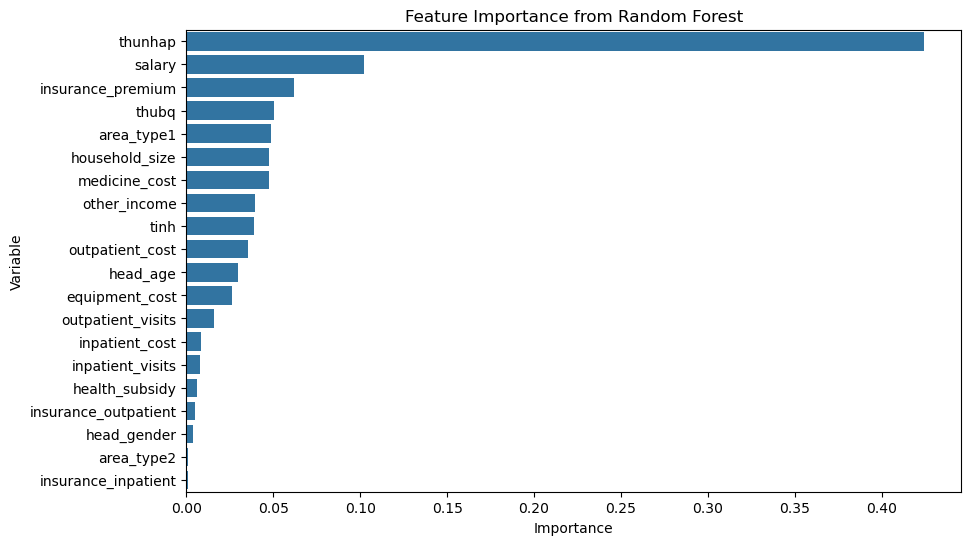


Các biến quan trọng được giữ lại: ['thunhap', 'salary', 'insurance_premium', 'thubq']


,thunhap,salary,insurance_premium,thubq,actual_food_2014
0,592600.0,297600.0,290.000000,9876,27163.0
1,225650.0,181500.0,290.000000,3760,14542.0
2,281894.0,69500.0,350.000000,4698,9611.0
3,114500.0,98000.0,396.568905,9541,2740.0
4,368180.0,330180.0,396.568905,15340,7351.5


In [37]:
# Sử dụng Random Forest để đánh giá tầm quan trọng của các đặc trưng
X = train_df.drop(['actual_food_2014', 'h_code'], axis=1)
y = train_df['actual_food_2014']
rf = RandomForestRegressor(n_estimators=100, random_state=42)
rf.fit(X, y)

# Tầm quan trọng của các đặc trưng
feature_importance = pd.DataFrame({'Variable': X.columns, 'Importance': rf.feature_importances_})
feature_importance = feature_importance.sort_values(by='Importance', ascending=False)
print("\nTầm quan trọng của các đặc trưng:")
print(feature_importance)

# Vẽ biểu đồ tầm quan trọng của các đặc trưng
plt.figure(figsize=(10, 6))
sns.barplot(x='Importance', y='Variable', data=feature_importance)
plt.title('Feature Importance from Random Forest')
plt.xlabel('Importance')
plt.ylabel('Variable')
plt.show()

# Chọn các biến quan trọng (giữ lại các biến có tầm quan trọng > 0.05)
important_features = feature_importance[feature_importance['Importance'] > 0.05]['Variable'].tolist()
print("\nCác biến quan trọng được giữ lại:", important_features)

# Tạo DataFrame mới chỉ chứa các biến quan trọng và actual_food_2014
train_df = train_df[important_features + ['actual_food_2014']]
train_df.head()

In [38]:
#  Tách features (X) và target (y)
continuous_vars_train = []
discrete_vars_train = []

for col in train_df.columns:
    if col != 'actual_food_2014':
        if train_df[col].dtype in ['int64', 'float64'] and train_df[col].nunique() > 15:
            continuous_vars_train.append(col)
        else:
            discrete_vars_train.append(col)

print("\nBiến liên tục:", continuous_vars_train)
print("Biến rời rạc:", discrete_vars_train)


Biến liên tục: ['thunhap', 'salary', 'insurance_premium', 'thubq']
Biến rời rạc: []


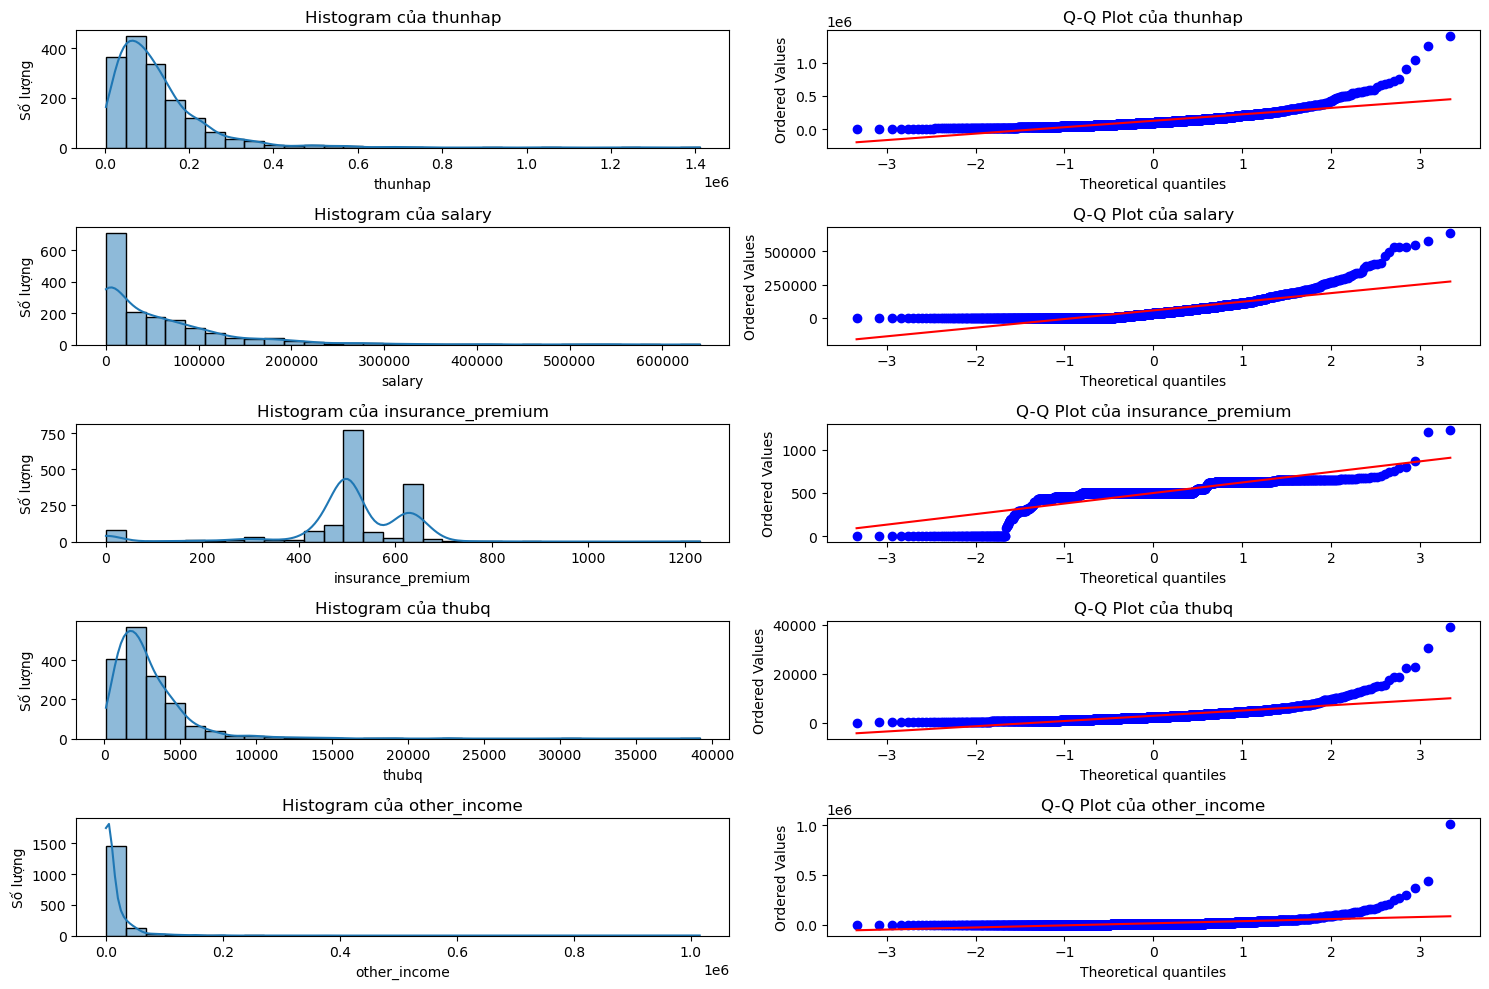


Kiểm định Shapiro-Wilk cho thunhap:
Statistic: 0.7391, p-value: 6.2606e-45
thunhap KHÔNG tuân theo phân phối chuẩn (p-value < 0.05).

Kiểm định Shapiro-Wilk cho salary:
Statistic: 0.7334, p-value: 2.9125e-45
salary KHÔNG tuân theo phân phối chuẩn (p-value < 0.05).

Kiểm định Shapiro-Wilk cho insurance_premium:
Statistic: 0.7246, p-value: 9.0482e-46
insurance_premium KHÔNG tuân theo phân phối chuẩn (p-value < 0.05).

Kiểm định Shapiro-Wilk cho thubq:
Statistic: 0.6889, p-value: 1.0791e-47
thubq KHÔNG tuân theo phân phối chuẩn (p-value < 0.05).

Kiểm định Shapiro-Wilk cho other_income:
Statistic: 0.3140, p-value: 3.7808e-61
other_income KHÔNG tuân theo phân phối chuẩn (p-value < 0.05).


In [39]:

from scipy.stats import shapiro, probplot

# Danh sách các biến liên tục
continuous_vars_test = ['thunhap', 'salary', 'insurance_premium', 'thubq', 'other_income']

# Thiết lập kích thước biểu đồ
plt.figure(figsize=(15, 10))

# Kiểm tra phân phối chuẩn cho từng biến
for i, var in enumerate(continuous_vars_test, 1):
    # 1. Histogram
    plt.subplot(len(continuous_vars_test), 2, 2*i-1)
    sns.histplot(test_df[var], kde=True, bins=30)
    plt.title(f'Histogram của {var}')
    plt.xlabel(var)
    plt.ylabel('Số lượng')

    # 2. Q-Q Plot
    plt.subplot(len(continuous_vars_test), 2, 2*i)
    probplot(test_df[var], dist="norm", plot=plt)
    plt.title(f'Q-Q Plot của {var}')


plt.tight_layout()
plt.show()

# 3. Kiểm định Shapiro-Wilk
for var in continuous_vars_test:
    stat, p_value = shapiro(test_df[var])
    print(f'\nKiểm định Shapiro-Wilk cho {var}:')
    print(f'Statistic: {stat:.4f}, p-value: {p_value:.4e}')
    if p_value < 0.05:
        print(f'{var} KHÔNG tuân theo phân phối chuẩn (p-value < 0.05).')
    else:
        print(f'{var} có thể tuân theo phân phối chuẩn (p-value >= 0.05).')

In [40]:
def transform_and_check(test_df, var):
    print(f"\n Biến đổi cho biến không chuẩn: {var}")
    
    # Bỏ qua nếu biến rời rạc
    if test_df[var].nunique() <= 10:
        return test_df
    
    # Xử lý giá trị âm/zero (dịch chuyển để tránh log(0))
    if (test_df[var] <= 0).any():
        shifted = test_df[var] - test_df[var].min() + 1  
    else:
        shifted = test_df[var]
    
    # Các phép biến đổi có thể dùng
    transformations = {
        'log': np.log(shifted)
    }

    # Kiểm tra và vẽ biểu đồ
    for trans_name_test, trans_data_test in transformations.items():
        if trans_data_test is None:
            continue
        
        new_col = f"{trans_name_test}_{var}"
        test_df[new_col] = trans_data_test 
        
        print(f"\n Sau {trans_name_test} transform → tạo cột mới: {new_col}")

        # Kiểm định Shapiro-Wilk
        try:
            stat, p = stats.shapiro(trans_data_test)
            print(f" Shapiro-Wilk: Statistics={stat:.3f}, p-value={p:.3f}")
            if p > 0.05:
                print(" Phân phối gần chuẩn hơn!")
        except Exception as e:
            print(f" Shapiro-Wilk test failed for {var} after {trans_name_test}: {e}")
            continue

        # Vẽ biểu đồ Histogram + Q-Q plot
        fig, axes = plt.subplots(1, 2, figsize=(10, 4))

        sns.histplot(trans_data_test, bins=30, kde=True, ax=axes[0], color='skyblue')
        axes[0].set_title(f"Histogram ({trans_name_test} - {var})")

        stats.probplot(trans_data_test, dist="norm", plot=axes[1])
        axes[1].set_title(f"Q-Q Plot ({trans_name_test} - {var})")

        plt.tight_layout()
        plt.show()

        # Xóa cột gốc nếu muốn
        test_df.drop(columns=[var], inplace=True, errors='ignore')
        
    return test_df

non_normal_vars_test = ['thunhap', 'salary', 'insurance_premium', 'thubq', 'other_income']

for var in non_normal_vars_test:
    test_df = transform_and_check(test_df, var)

test_df.drop(columns=['household_size'], inplace=True)
test_df.head()



 Biến đổi cho biến không chuẩn: thunhap

 Sau log transform → tạo cột mới: log_thunhap
 Shapiro-Wilk test failed for thunhap after log: name 'stats' is not defined

 Biến đổi cho biến không chuẩn: salary

 Sau log transform → tạo cột mới: log_salary
 Shapiro-Wilk test failed for salary after log: name 'stats' is not defined

 Biến đổi cho biến không chuẩn: insurance_premium

 Sau log transform → tạo cột mới: log_insurance_premium
 Shapiro-Wilk test failed for insurance_premium after log: name 'stats' is not defined

 Biến đổi cho biến không chuẩn: thubq

 Sau log transform → tạo cột mới: log_thubq
 Shapiro-Wilk test failed for thubq after log: name 'stats' is not defined

 Biến đổi cho biến không chuẩn: other_income

 Sau log transform → tạo cột mới: log_other_income
 Shapiro-Wilk test failed for other_income after log: name 'stats' is not defined


,thunhap,salary,insurance_premium,thubq,other_income,actual_food_2016,log_thunhap,log_salary,log_insurance_premium,log_thubq,log_other_income
0,642600.0,415600.0,457.000000,10710,155000.0,24578.0,13.373278,12.937481,6.126869,9.278933,11.951187
1,218100.0,208100.0,435.000000,3635,7000.0,11518.0,12.292709,12.245779,6.077642,8.198364,8.853808
2,367300.0,232000.0,650.000000,5101,22000.0,7707.0,12.813934,12.354497,6.478510,8.537192,9.998843
3,121700.0,97000.0,499.695701,10141,24400.0,4821.0,11.709314,11.482477,6.215999,9.224342,10.102379
4,274000.0,220000.0,499.695701,11416,54000.0,5480.7,12.520883,12.301387,6.215999,9.342771,10.896758


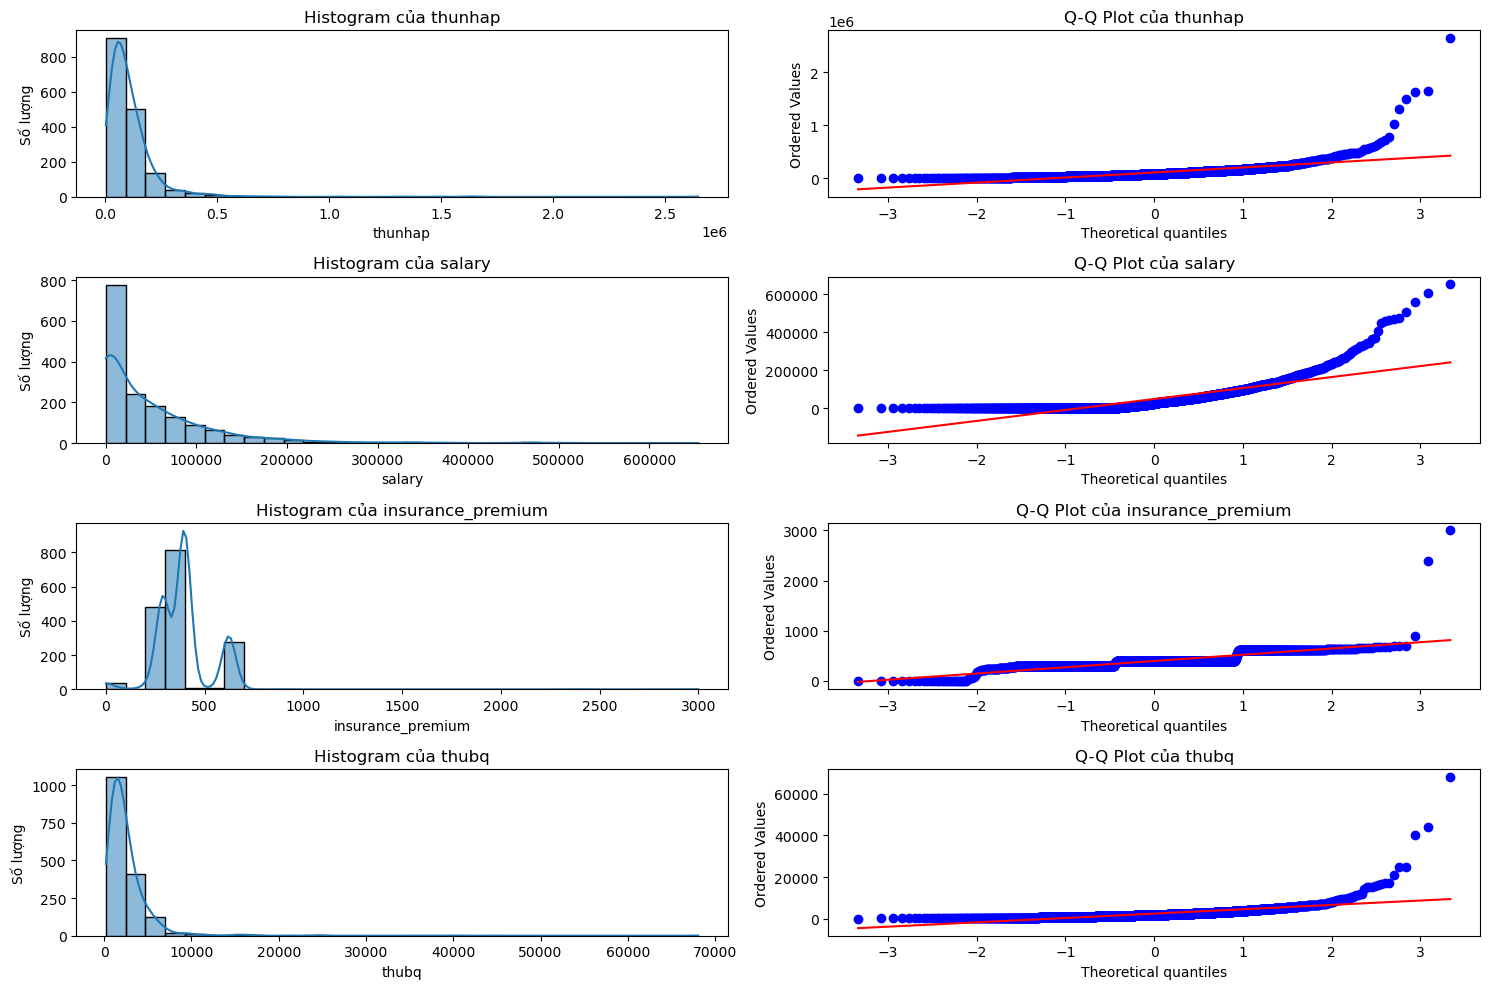


Kiểm định Shapiro-Wilk cho thunhap:
Statistic: 0.5167, p-value: 5.6086e-55
thunhap KHÔNG tuân theo phân phối chuẩn (p-value < 0.05).

Kiểm định Shapiro-Wilk cho salary:
Statistic: 0.6953, p-value: 2.3350e-47
salary KHÔNG tuân theo phân phối chuẩn (p-value < 0.05).

Kiểm định Shapiro-Wilk cho insurance_premium:
Statistic: 0.6830, p-value: 5.4549e-48
insurance_premium KHÔNG tuân theo phân phối chuẩn (p-value < 0.05).

Kiểm định Shapiro-Wilk cho thubq:
Statistic: 0.4681, p-value: 1.2433e-56
thubq KHÔNG tuân theo phân phối chuẩn (p-value < 0.05).


In [41]:
from scipy.stats import shapiro, probplot

# Danh sách các biến liên tục
continuous_vars_train =  ['thunhap', 'salary', 'insurance_premium', 'thubq']

# Thiết lập kích thước biểu đồ
plt.figure(figsize=(15, 10))

# Kiểm tra phân phối chuẩn cho từng biến
for i, var in enumerate(continuous_vars_train, 1):
    # 1. Histogram
    plt.subplot(len(continuous_vars_train), 2, 2*i-1)
    sns.histplot(train_df[var], kde=True, bins=30)
    plt.title(f'Histogram của {var}')
    plt.xlabel(var)
    plt.ylabel('Số lượng')

    # 2. Q-Q Plot
    plt.subplot(len(continuous_vars_train), 2, 2*i)
    probplot(train_df[var], dist="norm", plot=plt)  
    plt.title(f'Q-Q Plot của {var}')

plt.tight_layout()
plt.show()

# 3. Kiểm định Shapiro-Wilk
for var in continuous_vars_train:   
    stat, p_value = shapiro(train_df[var])
    print(f'\nKiểm định Shapiro-Wilk cho {var}:')
    print(f'Statistic: {stat:.4f}, p-value: {p_value:.4e}')
    if p_value < 0.05:
        print(f'{var} KHÔNG tuân theo phân phối chuẩn (p-value < 0.05).')
    else:
        print(f'{var} có thể tuân theo phân phối chuẩn (p-value >= 0.05).')

 Biến đổi cho biến không chuẩn: thunhap
  - Sau log transform → tạo cột mới: log_thunhap
    Shapiro-Wilk test failed for thunhap after log: name 'stats' is not defined
  - Lỗi khi biến đổi thunhap bằng log: name 'stats' is not defined
 Biến đổi cho biến không chuẩn: salary
  - Sau log transform → tạo cột mới: log_salary
    Shapiro-Wilk test failed for salary after log: name 'stats' is not defined
  - Lỗi khi biến đổi salary bằng log: name 'stats' is not defined
 Biến đổi cho biến không chuẩn: insurance_premium
  - Sau log transform → tạo cột mới: log_insurance_premium
    Shapiro-Wilk test failed for insurance_premium after log: name 'stats' is not defined
  - Lỗi khi biến đổi insurance_premium bằng log: name 'stats' is not defined
 Biến đổi cho biến không chuẩn: thubq
  - Sau log transform → tạo cột mới: log_thubq
    Shapiro-Wilk test failed for thubq after log: name 'stats' is not defined
  - Lỗi khi biến đổi thubq bằng log: name 'stats' is not defined


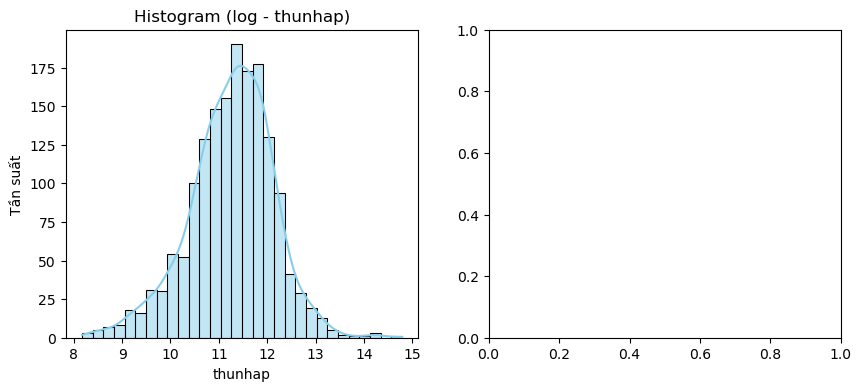

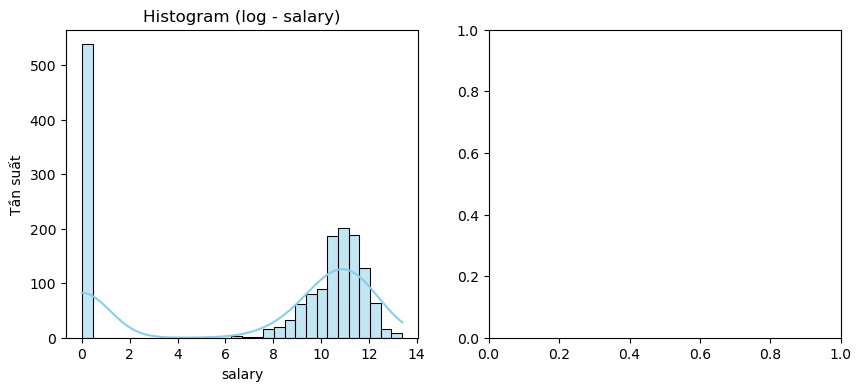

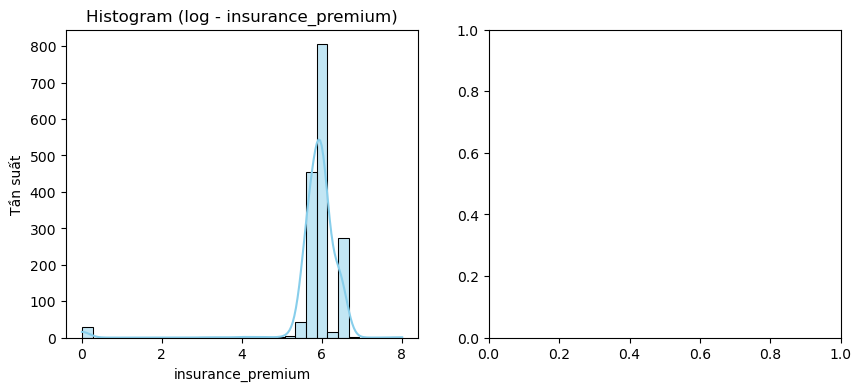

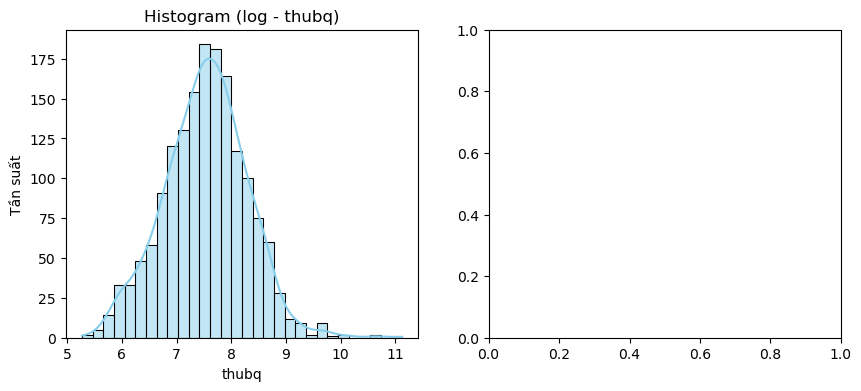

In [42]:
# Biến đổi và kiểm tra lại phân phối tập train
def transform_and_check(df, var):
    
    print(f" Biến đổi cho biến không chuẩn: {var}")

    # If the column doesn't exist, skip safely
    if var not in df.columns:
        print(f"  - Bỏ qua {var}: không có trong dataframe.")
        return df

    # Xử lý giá trị âm/zero (dịch chuyển để tránh log(0))
    try:
        series = df[var].astype(float)
    except Exception as e:
        print(f"  - Không thể chuyển {var} về float: {e}. Bỏ qua biến.")
        return df

    if (series <= 0).any():
        shifted = series - series.min() + 1
    else:
        shifted = series

    # Các phép biến đổi có thể dùng
    transformations = {
        'log': np.log(shifted)
    }

    # Thực hiện các phép biến đổi
    for trans_name, trans_data in transformations.items():
        try:
            new_col = f"{trans_name}_{var}"
            df[new_col] = trans_data
            print(f"  - Sau {trans_name} transform → tạo cột mới: {new_col}")

            # Kiểm định Shapiro-Wilk (bảo vệ bằng try/except)
            try:
                stat, p = stats.shapiro(trans_data)
                print(f"    Shapiro-Wilk: Statistics={stat:.3f}, p-value={p:.3f}")
                if p > 0.05:
                    print("    Phân phối gần chuẩn hơn!")
            except Exception as e:
                print(f"    Shapiro-Wilk test failed for {var} after {trans_name}: {e}")

            # Vẽ biểu đồ Histogram + Q-Q plot
            fig, axes = plt.subplots(1, 2, figsize=(10, 4))
            sns.histplot(trans_data, bins=30, kde=True, ax=axes[0], color='skyblue')
            axes[0].set_title(f"Histogram ({trans_name} - {var})")
            axes[0].set_xlabel(var)
            axes[0].set_ylabel("Tần suất")
            stats.probplot(trans_data, dist="norm", plot=axes[1])
            axes[1].set_title(f"Q-Q Plot ({trans_name} - {var})")
            plt.tight_layout()
            plt.show()

        except Exception as e:
            print(f"  - Lỗi khi biến đổi {var} bằng {trans_name}: {e}")
            # tiếp tục với các biến còn lại mà không phá hỏng df
            continue

    # Sau khi tạo cột biến đổi, loại bỏ các biến rời rạc nếu cần (nếu tồn tại)
    for col in list(discrete_vars_train):
        if col in df.columns:
            try:
                df.drop(columns=[col], inplace=True)
            except Exception as e:
                print(f"  - Không thể xóa {col}: {e}")

    # Cuối cùng loại bỏ cột gốc (nếu vẫn tồn tại)
    if var in df.columns:
        try:
            df.drop(columns=[var], inplace=True)
        except Exception as e:
            print(f"  - Không thể xóa cột gốc {var}: {e}")

    return df

# Áp dụng cho các biến không chuẩn (chỉ khi tồn tại trong train_df)
non_normal_vars_train = ['thunhap', 'salary', 'insurance_premium', 'thubq']
for var in non_normal_vars_train:
    if 'train_df' in globals() and isinstance(train_df, pd.DataFrame):
        train_df = transform_and_check(train_df, var)
    else:
        print("train_df không tồn tại hoặc không phải DataFrame. Bỏ qua vòng lặp biến đổi.")
        break



In [43]:
train_df.head()

,actual_food_2014,log_thunhap,log_salary,log_insurance_premium,log_thubq
0,27163.0,13.292275,12.603509,5.673323,9.197863
1,14542.0,12.326740,12.109016,5.673323,8.232174
2,9611.0,12.549286,11.149096,5.860786,8.454892
3,2740.0,11.648330,11.492733,5.985368,9.163354
4,7351.5,12.816327,12.707396,5.985368,9.638219


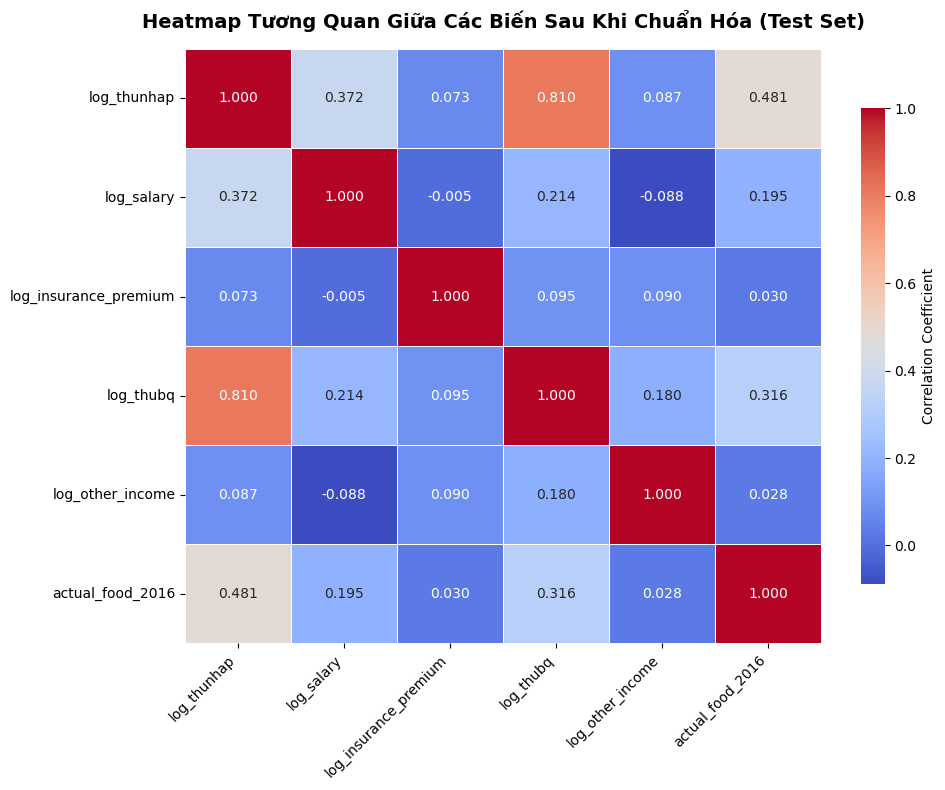

In [44]:
# Lấy danh sách các biến đã chuẩn 
normalized_vars_test = [col for col in test_df.columns if col.startswith('log_')]

# Thêm biến mục tiêu (nếu có trong dataframe)
if 'actual_food_2016' in test_df.columns:
    normalized_vars_test.append('actual_food_2016')

# Kiểm tra có biến nào đủ để vẽ không
if len(normalized_vars_test) < 2:
    print(" Không có đủ biến đã chuẩn để vẽ heatmap.")
else:
    plt.figure(figsize=(10, 8))
    sns.heatmap(
        test_df[normalized_vars_test].corr(),
        annot=True,
        cmap='coolwarm',
        fmt='.3f',
        linewidths=0.5,
        cbar_kws={'shrink': 0.8, 'label': 'Correlation Coefficient'}
    )


    plt.title('Heatmap Tương Quan Giữa Các Biến Sau Khi Chuẩn Hóa (Test Set)', 
              fontsize=14, fontweight='bold', pad=15)
    plt.xticks(rotation=45, ha='right')
    plt.yticks(rotation=0)
    plt.tight_layout()
    plt.show()


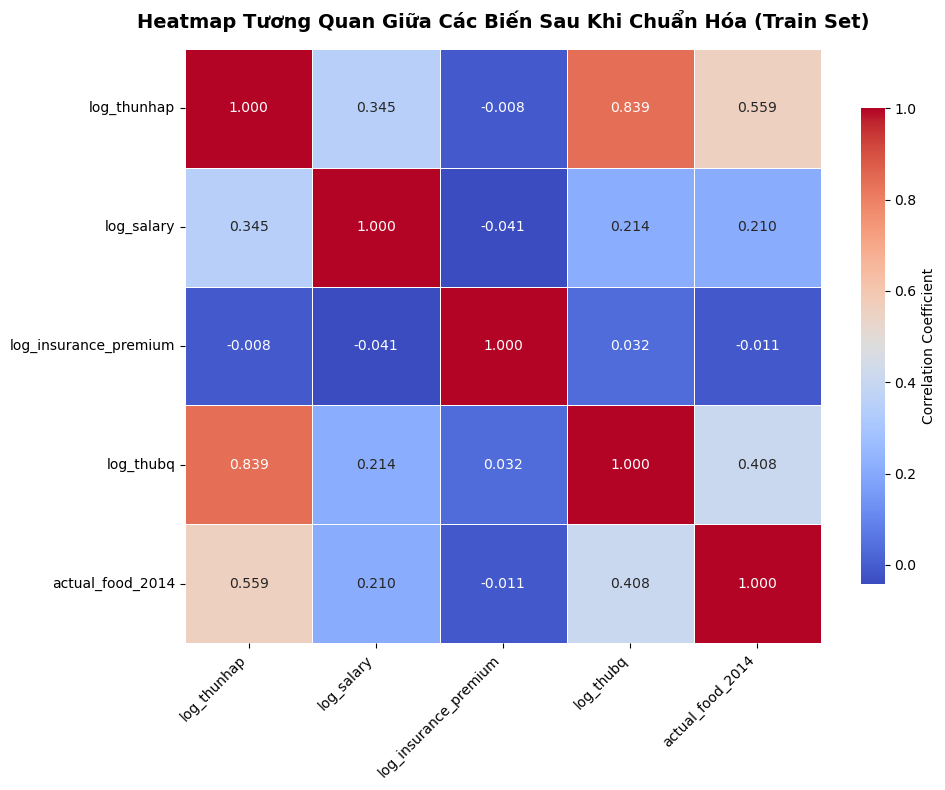

In [45]:
# Lấy danh sách các biến đã chuẩn 
normalized_vars_train = [col for col in train_df.columns if col.startswith('log_')]

# Thêm biến mục tiêu (nếu có trong dataframe)
if 'actual_food_2014' in train_df.columns:
    normalized_vars_train.append('actual_food_2014')
# Kiểm tra có biến nào đủ để vẽ không
if len(normalized_vars_train) < 2:
    print(" Không có đủ biến đã chuẩn để vẽ heatmap.")
else:
    plt.figure(figsize=(10, 8))
    sns.heatmap(
        train_df[normalized_vars_train].corr(),
        annot=True,
        cmap='coolwarm',
        fmt='.3f',
        linewidths=0.5,
        cbar_kws={'shrink': 0.8, 'label': 'Correlation Coefficient'}
    )


    plt.title('Heatmap Tương Quan Giữa Các Biến Sau Khi Chuẩn Hóa (Train Set)', 
              fontsize=14, fontweight='bold', pad=15)
    plt.xticks(rotation=45, ha='right')
    plt.yticks(rotation=0)
    plt.tight_layout()
    plt.show()

In [46]:
# Tách features và target
# Loại bỏ các cột không dùng cho modeling
cols_to_drop = ['h_code', 'actual_food_2014', 'actual_food_2016']
cols_to_drop = [col for col in cols_to_drop if col in train_df.columns]

X_train = train_df.drop(columns=cols_to_drop, errors='ignore')
y_train = train_df['actual_food_2014']

X_test = test_df.drop(columns=cols_to_drop, errors='ignore')
y_test = test_df['actual_food_2016']

print("DỮ LIỆU MODELING")
print(f"X_train shape: {X_train.shape}")
print(f"y_train shape: {y_train.shape}")
print(f"X_test shape: {X_test.shape}")
print(f"y_test shape: {y_test.shape}")
print(f"\nSố features: {X_train.shape[1]}")
print(f"\nFeature names:")
print(X_train.columns.tolist())

DỮ LIỆU MODELING
X_train shape: (1635, 4)
y_train shape: (1635,)
X_test shape: (1635, 11)
y_test shape: (1635,)

Số features: 4

Feature names:
['log_thunhap', 'log_salary', 'log_insurance_premium', 'log_thubq']


In [47]:
# Standardization (quan trọng cho Linear models)
from sklearn.preprocessing import StandardScaler

# Ensure we scale only the common feature columns present in both train and test
common_cols = [col for col in X_train.columns if col in X_test.columns]
if len(common_cols) == 0:
	raise ValueError("No common features between X_train and X_test to scale. Check your feature selection.")

# Keep the same column order for train and test
X_train_common = X_train[common_cols].copy()
X_test_common = X_test[common_cols].copy()

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train_common)
X_test_scaled = scaler.transform(X_test_common)

# Convert back to DataFrame để giữ column names and index
X_train_scaled = pd.DataFrame(X_train_scaled, columns=common_cols, index=X_train_common.index)
X_test_scaled = pd.DataFrame(X_test_scaled, columns=common_cols, index=X_test_common.index)

print("\n Standardization completed")
print(f"   Features used: {common_cols}")
print(f"   Mean (train): {X_train_scaled.mean().mean():.6f}")
print(f"   Std (train): {X_train_scaled.std().mean():.6f}")


 Standardization completed
   Features used: ['log_thunhap', 'log_salary', 'log_insurance_premium', 'log_thubq']
   Mean (train): 0.000000
   Std (train): 1.000306


DỮ LIỆU TRAIN (2014) - TẬP GỐC
Shape X_train: (1635, 4)
Shape y_train: (1635,)

DỮ LIỆU TEST (2016) - TẬP ÁP DỤNG
Shape X_test: (1635, 4)
Shape y_test: (1635,)
RANDOM FOREST REGRESSION

Kết quả Random Forest:
  MSE:  16,975,933.00
  RMSE: 4,120.19
  MAE:  1,948.30
  R²:   0.1995

Feature Importance:
  log_thunhap: 0.5934
  log_salary: 0.1699
  log_insurance_premium: 0.0958
  log_thubq: 0.1410
LINEAR REGRESSION

Kết quả Linear Regression:
  MSE:  16,012,098.52
  RMSE: 4,001.51
  MAE:  1,935.68
  R²:   0.2450

Coefficients (hệ số):
              Feature  Coefficient
          log_thunhap  2749.572454
           log_salary     8.431136
log_insurance_premium     6.452641
            log_thubq  -776.662732

Intercept: 4484.49
SO SÁNH CÁC MODEL
            Model        RMSE         MAE       R²
    Random Forest 4120.186040 1948.296161 0.199514
Linear Regression 4001.512029 1935.679022 0.244963

 Model tốt nhất: Linear Regression (R² = 0.2450)


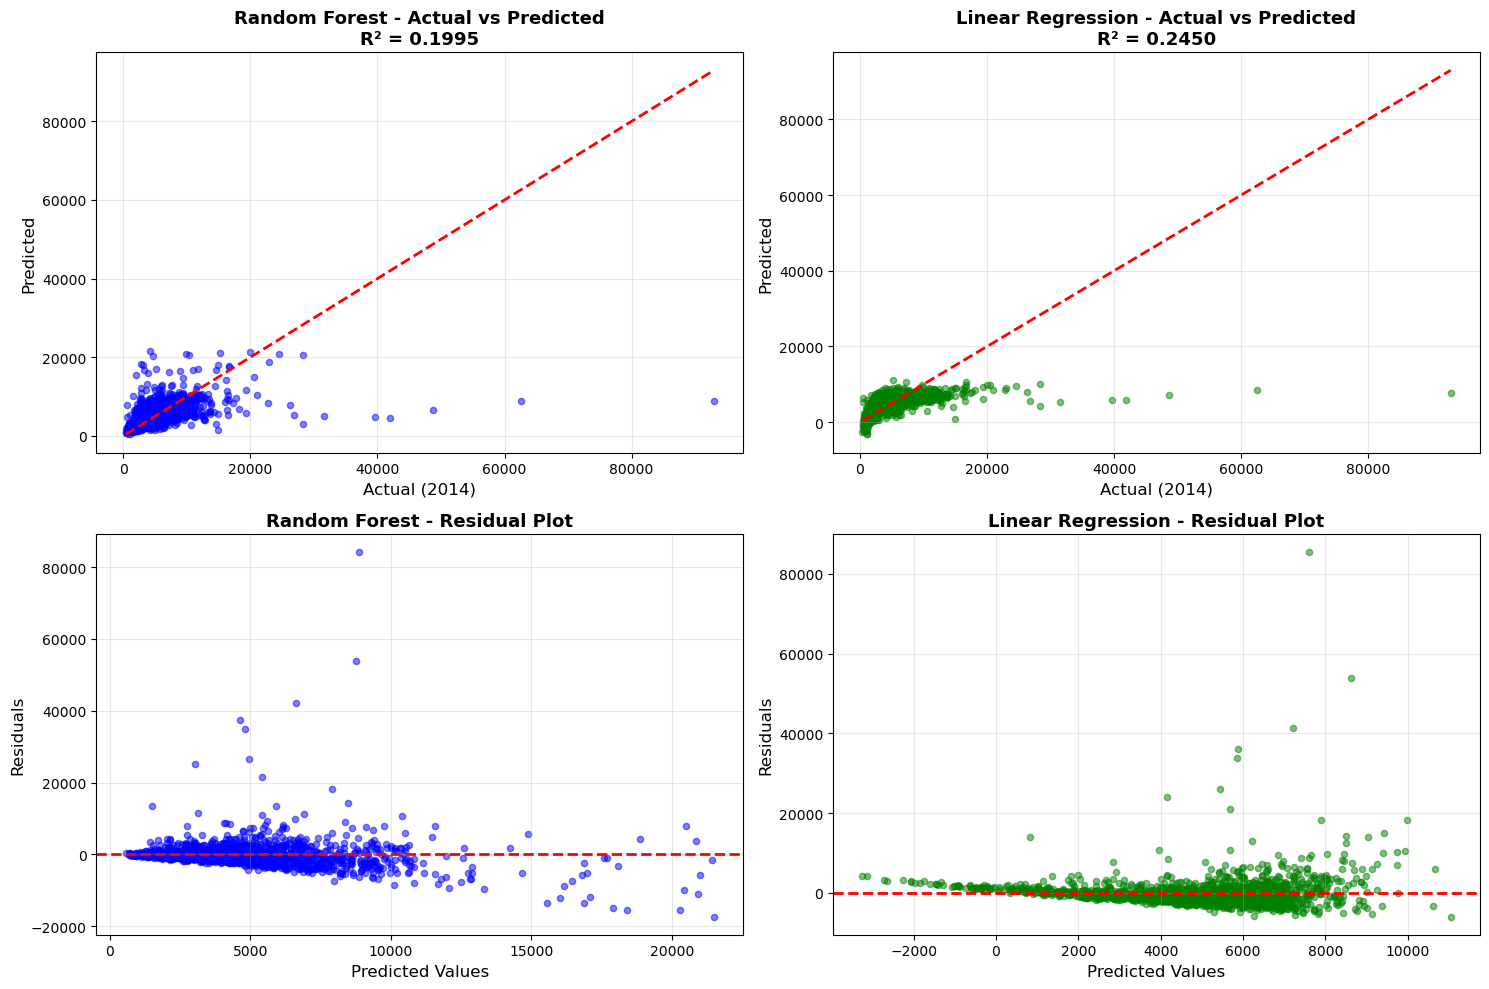

PHÂN TÍCH GROWTH RATE: ACTUAL (2014 → 2016)

LOG DIFFERENCE ANALYSIS (2014 - 2016)
Mean log difference:   0.0696
Median log difference: 0.0729
Std log difference:    0.5556

Interpretation:
Average growth rate:   7.21%
VISUALIZATION - DỰ ĐOÁN CHI PHÍ THỰC PHẨM


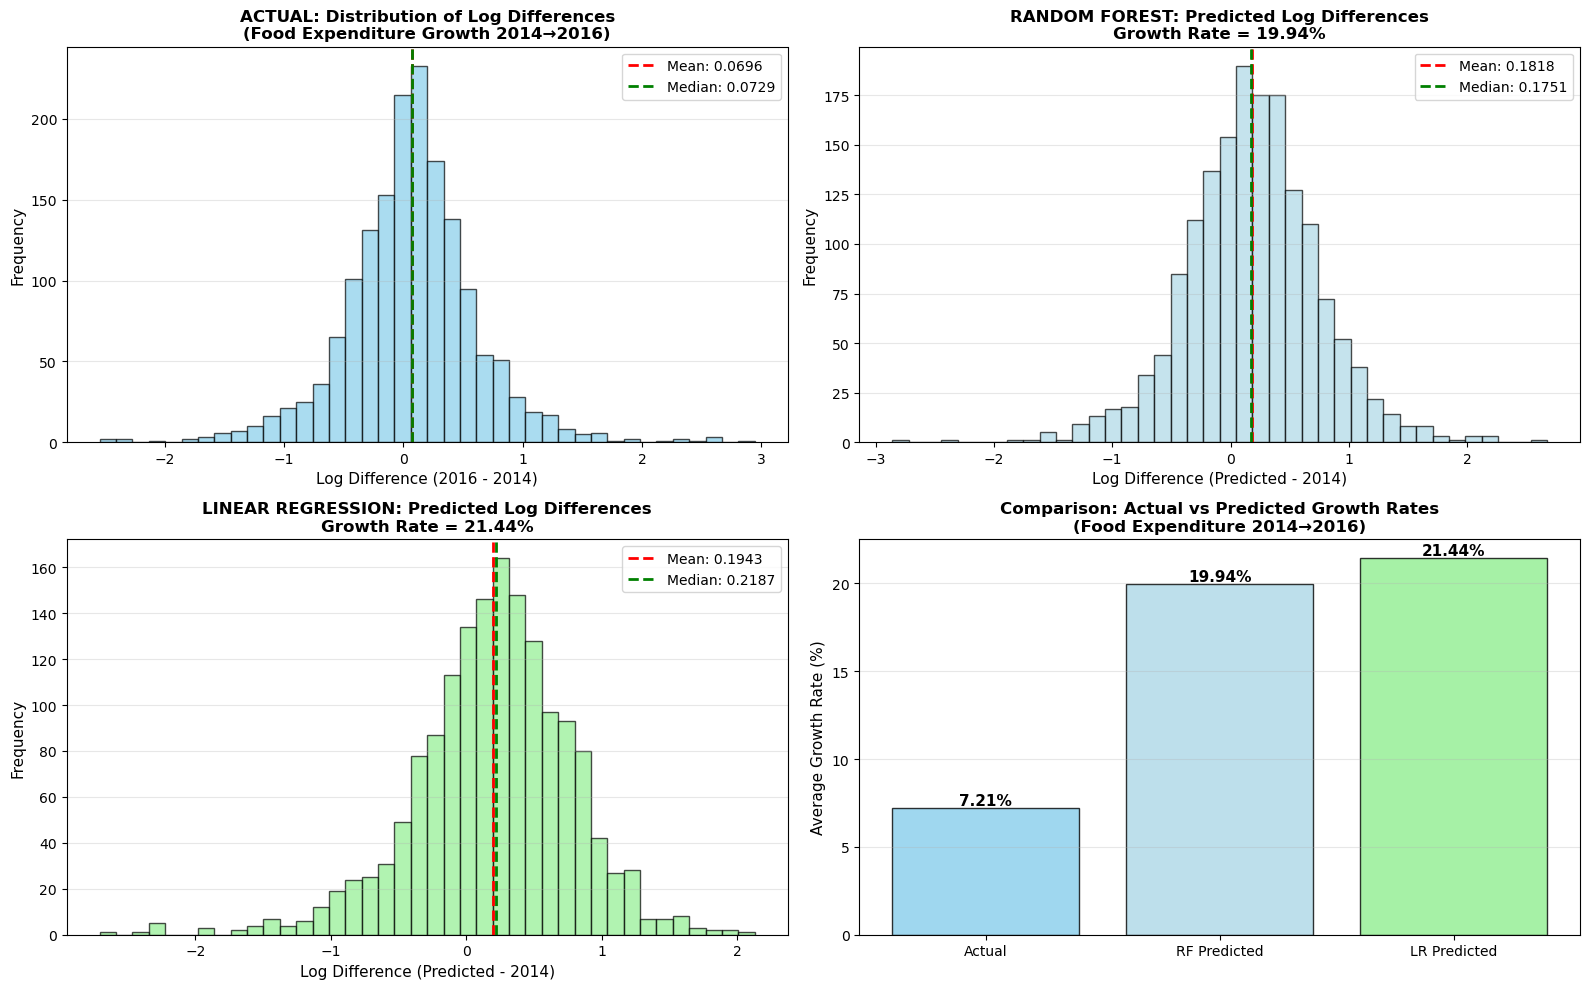

SO SÁNH GROWTH RATES

Actual Growth Rate (2014 → 2016):          7.21%
Random Forest Predicted Growth Rate:       19.94%
Linear Regression Predicted Growth Rate:   21.44%

Sai số dự đoán Growth Rate:
Random Forest:      12.73 percentage points
Linear Regression:  14.23 percentage points

 Random Forest dự đoán growth rate chính xác hơn
PHÂN PHỐI DỰ ĐOÁN CHI PHÍ THỰC PHẨM 2016


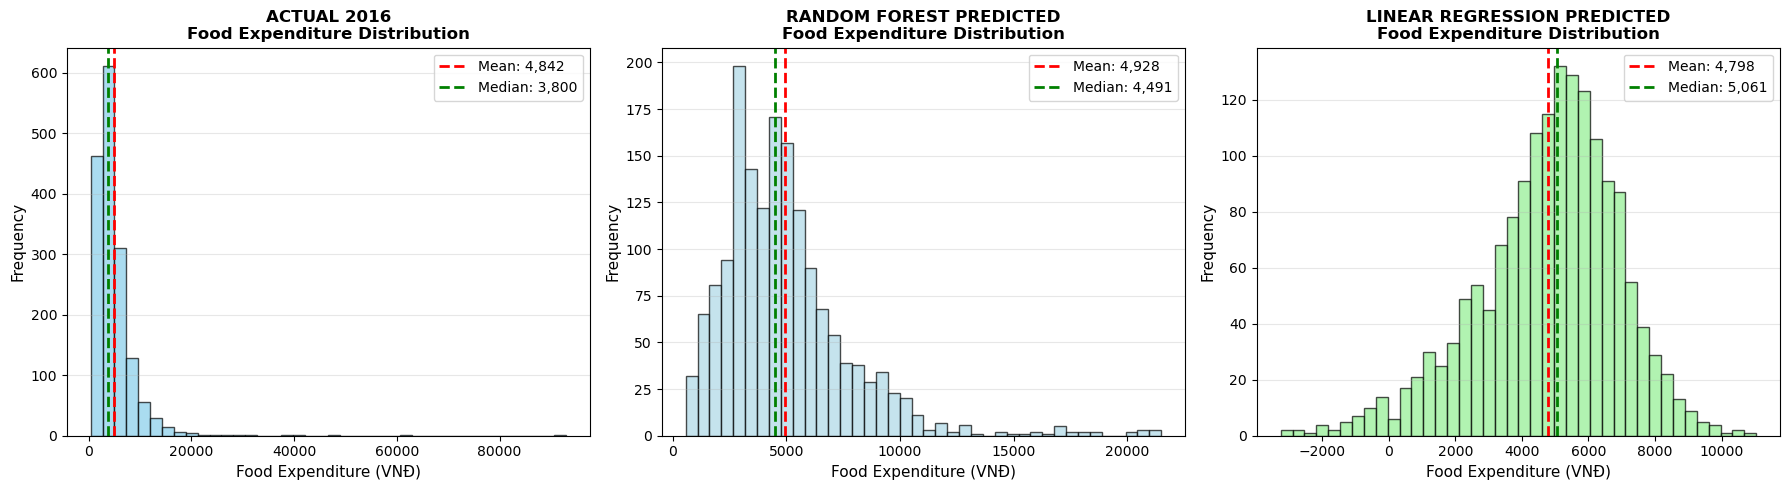

THỐNG KÊ CHI PHÍ THỰC PHẨM 2016
Metric Actual 2016 RF Predicted LR Predicted
  Mean       4,842        4,928        4,798
Median       3,800        4,491        5,061
   Std       4,607        2,859        2,120
   Min         376          563       -3,245
   Max      92,958       21,495       11,042
TÓM TẮT

 PERFORMANCE:
Best Model: Linear Regression
  R²: 0.2450
  RMSE: 4,002 VNĐ

 GROWTH RATE (2014 → 2016):
  Actual:      7.21%
  RF Pred:     19.94%
  LR Pred:     21.44%

 AVERAGE FOOD EXPENDITURE 2016:
  Actual:      4,842 VNĐ
  RF Pred:     4,928 VNĐ
  LR Pred:     4,798 VNĐ


In [48]:
#  TRAINING & EVALUATION + VISUALIZATION DỰ ĐOÁN CHI PHÍ
# Lấy features đã chọn
important_features = ['log_thunhap', 'log_salary', 'log_insurance_premium','log_thubq']

# Chuẩn bị dữ liệu train (2014)
X_train = train_df[important_features].copy()
y_train = train_df['actual_food_2014'].copy()

# Chuẩn bị dữ liệu test (2016)
X_test = test_df[important_features].copy()
y_test = test_df['actual_food_2016'].copy()

print("DỮ LIỆU TRAIN (2014) - TẬP GỐC")
print(f"Shape X_train: {X_train.shape}")
print(f"Shape y_train: {y_train.shape}")

print("\nDỮ LIỆU TEST (2016) - TẬP ÁP DỤNG")
print(f"Shape X_test: {X_test.shape}")
print(f"Shape y_test: {y_test.shape}")

# STANDARDIZATION (cho Linear Regression)
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Chuyển về DataFrame
X_train_scaled = pd.DataFrame(X_train_scaled, columns=important_features, index=X_train.index)
X_test_scaled = pd.DataFrame(X_test_scaled, columns=important_features, index=X_test.index)

# 1. RANDOM FOREST MODEL
print("RANDOM FOREST REGRESSION")

rf_model = RandomForestRegressor(
    n_estimators=100, 
    random_state=42, 
    max_depth=10, 
    min_samples_split=5,
    n_jobs=-1
)
rf_model.fit(X_train, y_train)

# Predict trên tập 2016
y_pred_rf = rf_model.predict(X_test)

# Đánh giá
from sklearn.metrics import mean_absolute_error

mse_rf = mean_squared_error(y_test, y_pred_rf)
rmse_rf = np.sqrt(mse_rf)
r2_rf = r2_score(y_test, y_pred_rf)
mae_rf = mean_absolute_error(y_test, y_pred_rf)

print(f"\nKết quả Random Forest:")
print(f"  MSE:  {mse_rf:,.2f}")
print(f"  RMSE: {rmse_rf:,.2f}")
print(f"  MAE:  {mae_rf:,.2f}")
print(f"  R²:   {r2_rf:.4f}")

# Feature Importance
print(f"\nFeature Importance:")
for feat, imp in zip(important_features, rf_model.feature_importances_):
    print(f"  {feat}: {imp:.4f}")

# 2. LINEAR REGRESSION MODEL
print("LINEAR REGRESSION")

lr_model = LinearRegression()
lr_model.fit(X_train_scaled, y_train)

# Predict trên tập 2016
y_pred_lr = lr_model.predict(X_test_scaled)

# Đánh giá
mse_lr = mean_squared_error(y_test, y_pred_lr)
rmse_lr = np.sqrt(mse_lr)
r2_lr = r2_score(y_test, y_pred_lr)
mae_lr = mean_absolute_error(y_test, y_pred_lr)

print(f"\nKết quả Linear Regression:")
print(f"  MSE:  {mse_lr:,.2f}")
print(f"  RMSE: {rmse_lr:,.2f}")
print(f"  MAE:  {mae_lr:,.2f}")
print(f"  R²:   {r2_lr:.4f}")

# Coefficients
print(f"\nCoefficients (hệ số):")
coef_df = pd.DataFrame({
    'Feature': important_features, 
    'Coefficient': lr_model.coef_
}).sort_values('Coefficient', ascending=False)
print(coef_df.to_string(index=False))
print(f"\nIntercept: {lr_model.intercept_:.2f}")

# 3. SO SÁNH KẾT QUẢ
print("SO SÁNH CÁC MODEL")

comparison = pd.DataFrame({
    'Model': ['Random Forest', 'Linear Regression'],
    'RMSE': [rmse_rf, rmse_lr],
    'MAE': [mae_rf, mae_lr],
    'R²': [r2_rf, r2_lr]
})
print(comparison.to_string(index=False))

# Model tốt nhất
best_model = 'Random Forest' if r2_rf > r2_lr else 'Linear Regression'
print(f"\n Model tốt nhất: {best_model} (R² = {max(r2_rf, r2_lr):.4f})")

# 4. VISUALIZATION - ACTUAL VS PREDICTED
fig, axes = plt.subplots(2, 2, figsize=(15, 10))

# Row 1: Actual vs Predicted
axes[0, 0].scatter(y_test, y_pred_rf, alpha=0.5, color='blue', s=20)
axes[0, 0].plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2)
axes[0, 0].set_xlabel('Actual (2014)', fontsize=12)
axes[0, 0].set_ylabel('Predicted', fontsize=12)
axes[0, 0].set_title(f'Random Forest - Actual vs Predicted\nR² = {r2_rf:.4f}', fontsize=13, fontweight='bold')
axes[0, 0].grid(True, alpha=0.3)

axes[0, 1].scatter(y_test, y_pred_lr, alpha=0.5, color='green', s=20)
axes[0, 1].plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2)
axes[0, 1].set_xlabel('Actual (2014)', fontsize=12)
axes[0, 1].set_ylabel('Predicted', fontsize=12)
axes[0, 1].set_title(f'Linear Regression - Actual vs Predicted\nR² = {r2_lr:.4f}', fontsize=13, fontweight='bold')
axes[0, 1].grid(True, alpha=0.3)

# Row 2: Residuals
residuals_rf = y_test - y_pred_rf
residuals_lr = y_test - y_pred_lr

axes[1, 0].scatter(y_pred_rf, residuals_rf, alpha=0.5, color='blue', s=20)
axes[1, 0].axhline(y=0, color='r', linestyle='--', lw=2)
axes[1, 0].set_xlabel('Predicted Values', fontsize=12)
axes[1, 0].set_ylabel('Residuals', fontsize=12)
axes[1, 0].set_title('Random Forest - Residual Plot', fontsize=13, fontweight='bold')
axes[1, 0].grid(True, alpha=0.3)

axes[1, 1].scatter(y_pred_lr, residuals_lr, alpha=0.5, color='green', s=20)
axes[1, 1].axhline(y=0, color='r', linestyle='--', lw=2)
axes[1, 1].set_xlabel('Predicted Values', fontsize=12)
axes[1, 1].set_ylabel('Residuals', fontsize=12)
axes[1, 1].set_title('Linear Regression - Residual Plot', fontsize=13, fontweight='bold')
axes[1, 1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# 5. PHÂN TÍCH LOG DIFFERENCE 
print("PHÂN TÍCH GROWTH RATE: ACTUAL (2014 → 2016)")

# Tính log difference 
log_2014 = np.log(y_train)
log_2016 = np.log(y_test)
log_diff_actual = log_2016 - log_2014

mean_diff = log_diff_actual.mean()
median_diff = log_diff_actual.median()
std_diff = log_diff_actual.std()

print("\nLOG DIFFERENCE ANALYSIS (2014 - 2016)")
print(f"Mean log difference:   {mean_diff:.4f}")
print(f"Median log difference: {median_diff:.4f}")
print(f"Std log difference:    {std_diff:.4f}")
print(f"\nInterpretation:")
print(f"Average growth rate:   {(np.exp(mean_diff) - 1) * 100:.2f}%")

# 6. VISUALIZATION - PHÂN TÍCH DỰ ĐOÁN CHI PHÍ THỰC PHẨM
print("VISUALIZATION - DỰ ĐOÁN CHI PHÍ THỰC PHẨM")

# Plot 1: Distribution of Log Differences (ACTUAL) 
fig, axes = plt.subplots(2, 2, figsize=(16, 10))

# Subplot 1: Actual Log Difference (2016 - 2014)
axes[0, 0].hist(log_diff_actual, bins=40, color='skyblue', edgecolor='black', alpha=0.7)
axes[0, 0].axvline(mean_diff, color='red', linestyle='--', linewidth=2, 
                   label=f'Mean: {mean_diff:.4f}')
axes[0, 0].axvline(median_diff, color='green', linestyle='--', linewidth=2, 
                   label=f'Median: {median_diff:.4f}')
axes[0, 0].set_xlabel('Log Difference (2016 - 2014)', fontsize=11)
axes[0, 0].set_ylabel('Frequency', fontsize=11)
axes[0, 0].set_title('ACTUAL: Distribution of Log Differences\n(Food Expenditure Growth 2014→2016)', 
                     fontsize=12, fontweight='bold')
axes[0, 0].legend(fontsize=10)
axes[0, 0].grid(True, alpha=0.3, axis='y')

# Subplot 2: Predicted Log Difference - Random Forest
log_pred_rf = np.log(y_pred_rf)
log_diff_pred_rf = log_pred_rf - log_2014

mean_diff_rf = log_diff_pred_rf.mean()
median_diff_rf = log_diff_pred_rf.median()

axes[0, 1].hist(log_diff_pred_rf, bins=40, color='lightblue', edgecolor='black', alpha=0.7)
axes[0, 1].axvline(mean_diff_rf, color='red', linestyle='--', linewidth=2, 
                   label=f'Mean: {mean_diff_rf:.4f}')
axes[0, 1].axvline(median_diff_rf, color='green', linestyle='--', linewidth=2, 
                   label=f'Median: {median_diff_rf:.4f}')
axes[0, 1].set_xlabel('Log Difference (Predicted - 2014)', fontsize=11)
axes[0, 1].set_ylabel('Frequency', fontsize=11)
axes[0, 1].set_title('RANDOM FOREST: Predicted Log Differences\nGrowth Rate = {:.2f}%'.format((np.exp(mean_diff_rf) - 1) * 100), 
                     fontsize=12, fontweight='bold')
axes[0, 1].legend(fontsize=10)
axes[0, 1].grid(True, alpha=0.3, axis='y')

# Subplot 3: Predicted Log Difference - Linear Regression
log_pred_lr = np.log(y_pred_lr)
log_diff_pred_lr = log_pred_lr - log_2014

mean_diff_lr = log_diff_pred_lr.mean()
median_diff_lr = log_diff_pred_lr.median()

axes[1, 0].hist(log_diff_pred_lr, bins=40, color='lightgreen', edgecolor='black', alpha=0.7)
axes[1, 0].axvline(mean_diff_lr, color='red', linestyle='--', linewidth=2, 
                   label=f'Mean: {mean_diff_lr:.4f}')
axes[1, 0].axvline(median_diff_lr, color='green', linestyle='--', linewidth=2, 
                   label=f'Median: {median_diff_lr:.4f}')
axes[1, 0].set_xlabel('Log Difference (Predicted - 2014)', fontsize=11)
axes[1, 0].set_ylabel('Frequency', fontsize=11)
axes[1, 0].set_title('LINEAR REGRESSION: Predicted Log Differences\nGrowth Rate = {:.2f}%'.format((np.exp(mean_diff_lr) - 1) * 100), 
                     fontsize=12, fontweight='bold')
axes[1, 0].legend(fontsize=10)
axes[1, 0].grid(True, alpha=0.3, axis='y')

# Subplot 4: Comparison of Growth Rates
growth_rates = {
    'Actual': (np.exp(mean_diff) - 1) * 100,
    'RF Predicted': (np.exp(mean_diff_rf) - 1) * 100,
    'LR Predicted': (np.exp(mean_diff_lr) - 1) * 100
}

colors_bar = ['skyblue', 'lightblue', 'lightgreen']
bars = axes[1, 1].bar(growth_rates.keys(), growth_rates.values(), 
                      color=colors_bar, edgecolor='black', alpha=0.8)
axes[1, 1].set_ylabel('Average Growth Rate (%)', fontsize=11)
axes[1, 1].set_title('Comparison: Actual vs Predicted Growth Rates\n(Food Expenditure 2014→2016)', 
                     fontsize=12, fontweight='bold')
axes[1, 1].grid(True, alpha=0.3, axis='y')
axes[1, 1].axhline(y=0, color='black', linestyle='-', linewidth=0.5)

# Thêm giá trị trên cột
for bar, (name, value) in zip(bars, growth_rates.items()):
    height = bar.get_height()
    axes[1, 1].text(bar.get_x() + bar.get_width()/2., height,
                    f'{value:.2f}%',
                    ha='center', va='bottom', fontsize=11, fontweight='bold')

plt.tight_layout()
plt.show()

# 7. PHÂN TÍCH SO SÁNH GROWTH RATES
print("SO SÁNH GROWTH RATES")

print(f"\nActual Growth Rate (2014 → 2016):          {(np.exp(mean_diff) - 1) * 100:.2f}%")
print(f"Random Forest Predicted Growth Rate:       {(np.exp(mean_diff_rf) - 1) * 100:.2f}%")
print(f"Linear Regression Predicted Growth Rate:   {(np.exp(mean_diff_lr) - 1) * 100:.2f}%")

# Tính sai số của growth rate predictions
error_rf = abs((np.exp(mean_diff_rf) - 1) * 100 - (np.exp(mean_diff) - 1) * 100)
error_lr = abs((np.exp(mean_diff_lr) - 1) * 100 - (np.exp(mean_diff) - 1) * 100)

print(f"\nSai số dự đoán Growth Rate:")
print(f"Random Forest:      {error_rf:.2f} percentage points")
print(f"Linear Regression:  {error_lr:.2f} percentage points")

if error_rf < error_lr:
    print(f"\n Random Forest dự đoán growth rate chính xác hơn")
else:
    print(f"\n Linear Regression dự đoán growth rate chính xác hơn")

# 8. VISUALIZATION - PHÂN PHỐI DỰ ĐOÁN CHI PHÍ
print("PHÂN PHỐI DỰ ĐOÁN CHI PHÍ THỰC PHẨM 2016")

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Plot 1: Actual 2016
axes[0].hist(y_test, bins=40, color='skyblue', edgecolor='black', alpha=0.7)
axes[0].axvline(y_test.mean(), color='red', linestyle='--', linewidth=2, 
                label=f'Mean: {y_test.mean():,.0f}')
axes[0].axvline(y_test.median(), color='green', linestyle='--', linewidth=2, 
                label=f'Median: {y_test.median():,.0f}')
axes[0].set_xlabel('Food Expenditure (VNĐ)', fontsize=11)
axes[0].set_ylabel('Frequency', fontsize=11)
axes[0].set_title('ACTUAL 2016\nFood Expenditure Distribution', fontsize=12, fontweight='bold')
axes[0].legend(fontsize=10)
axes[0].grid(True, alpha=0.3, axis='y')

# Plot 2: Random Forest Predicted
axes[1].hist(y_pred_rf, bins=40, color='lightblue', edgecolor='black', alpha=0.7)
axes[1].axvline(y_pred_rf.mean(), color='red', linestyle='--', linewidth=2, 
                label=f'Mean: {y_pred_rf.mean():,.0f}')
axes[1].axvline(np.median(y_pred_rf), color='green', linestyle='--', linewidth=2, 
                label=f'Median: {np.median(y_pred_rf):,.0f}')
axes[1].set_xlabel('Food Expenditure (VNĐ)', fontsize=11)
axes[1].set_ylabel('Frequency', fontsize=11)
axes[1].set_title('RANDOM FOREST PREDICTED\nFood Expenditure Distribution', fontsize=12, fontweight='bold')
axes[1].legend(fontsize=10)
axes[1].grid(True, alpha=0.3, axis='y')

# Plot 3: Linear Regression Predicted
axes[2].hist(y_pred_lr, bins=40, color='lightgreen', edgecolor='black', alpha=0.7)
axes[2].axvline(y_pred_lr.mean(), color='red', linestyle='--', linewidth=2, 
                label=f'Mean: {y_pred_lr.mean():,.0f}')
axes[2].axvline(np.median(y_pred_lr), color='green', linestyle='--', linewidth=2, 
                label=f'Median: {np.median(y_pred_lr):,.0f}')
axes[2].set_xlabel('Food Expenditure (VNĐ)', fontsize=11)
axes[2].set_ylabel('Frequency', fontsize=11)
axes[2].set_title('LINEAR REGRESSION PREDICTED\nFood Expenditure Distribution', fontsize=12, fontweight='bold')
axes[2].legend(fontsize=10)
axes[2].grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.show()

# 9. THỐNG KÊ CHI PHÍ DỰ ĐOÁN
print("THỐNG KÊ CHI PHÍ THỰC PHẨM 2016")

stats_comparison = pd.DataFrame({
    'Metric': ['Mean', 'Median', 'Std', 'Min', 'Max'],
    'Actual 2016': [
        y_test.mean(),
        y_test.median(),
        y_test.std(),
        y_test.min(),
        y_test.max()
    ],
    'RF Predicted': [
        y_pred_rf.mean(),
        np.median(y_pred_rf),
        y_pred_rf.std(),
        y_pred_rf.min(),
        y_pred_rf.max()
    ],
    'LR Predicted': [
        y_pred_lr.mean(),
        np.median(y_pred_lr),
        y_pred_lr.std(),
        y_pred_lr.min(),
        y_pred_lr.max()
    ]
})

# Format numbers
for col in ['Actual 2016', 'RF Predicted', 'LR Predicted']:
    stats_comparison[col] = stats_comparison[col].apply(lambda x: f'{x:,.0f}')

print(stats_comparison.to_string(index=False))

# 10. TÓM TẮT CUỐI CÙNG
print("TÓM TẮT")

print(f"\n PERFORMANCE:")
print(f"Best Model: {best_model}")
print(f"  R²: {max(r2_rf, r2_lr):.4f}")
print(f"  RMSE: {min(rmse_rf, rmse_lr):,.0f} VNĐ")

print(f"\n GROWTH RATE (2014 → 2016):")
print(f"  Actual:      {(np.exp(mean_diff) - 1) * 100:.2f}%")
print(f"  RF Pred:     {(np.exp(mean_diff_rf) - 1) * 100:.2f}%")
print(f"  LR Pred:     {(np.exp(mean_diff_lr) - 1) * 100:.2f}%")

print(f"\n AVERAGE FOOD EXPENDITURE 2016:")
print(f"  Actual:      {y_test.mean():,.0f} VNĐ")
print(f"  RF Pred:     {y_pred_rf.mean():,.0f} VNĐ")
print(f"  LR Pred:     {y_pred_lr.mean():,.0f} VNĐ")
